# GAIRA V6 — Detection Gate: interactive metric & threshold validation

**Purpose.** Inspect and tune the Stage-0 detection metrics/thresholds *before* they are frozen into
the V6 pipeline. The gate must reflect spectroscopy, not convenience: strong Ag chemisorbers
(adenine, ergothioneine, urate, xanthine) must clearly PASS, and weak/invisible analytes
(glucose, tyrosine, oleate) must FAIL for physically justifiable reasons (poor adsorption →
irreproducible, structureless Ag-SERS).

Run top-to-bottom. The last markdown cell records the validation outcome. Nothing here modifies the
frozen atlas.

In [1]:
import json, sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
BASE = Path('/Users/surajpg/projects/GAIRA/results/v5_rebuild/detection_gate_v6')
df = pd.read_csv(BASE/'tables/detection_metrics.csv')
S = json.loads((BASE/'artifacts/detection_summary.json').read_text())
V = np.load(BASE/'artifacts/detection_spectra.npz', allow_pickle=True)
print('analytes:', len(df), '| weights:', S['weights'])
print('tier thresholds:', S['tier_thresholds'], '| pass >=', S['detection_pass_threshold'])
df[['analyte','broad_family','rep_pearson','peak_snr','var_concentration','repro_peaks','detection_confidence','detection_tier']]

analytes: 51 | weights: {'rep_pearson': 0.45, 'rep_spearman': 0.1, 'peak_snr': 0.2, 'var_concentration': 0.15, 'repro_peaks': 0.1}
tier thresholds: {'GOOD': 0.65, 'MODERATE': 0.5, 'POOR': 0.4, 'UNDETECTABLE': 0.0} | pass >= 0.5


,analyte,broad_family,rep_pearson,peak_snr,var_concentration,repro_peaks,detection_confidence,detection_tier
0,xanthine,purine,0.994879,159.182057,0.268878,14,0.9948,GOOD
1,ergothioneine,cofactor,0.987562,67.366619,0.299375,13,0.9723,GOOD
2,urate,purine,0.990034,67.574340,0.113273,14,0.8942,GOOD
3,albumin,protein,0.908677,20.297658,0.259267,9,0.8525,GOOD
4,cholesterol,lipid,0.929428,8.299650,0.272172,7,0.8057,GOOD
5,guanine,purine,0.879128,7.320717,0.209262,9,0.7659,GOOD
6,glutathione,cofactor,0.847222,7.444194,0.209660,7,0.7366,GOOD
7,urea,small_nitrogenous,0.880003,6.571497,0.207425,4,0.6963,GOOD
8,hypoxanthine,purine,0.787515,5.613948,0.211182,5,0.6539,GOOD
9,acetoacetate,organic_acid,0.709699,12.717858,0.110211,11,0.6538,GOOD


## 1 · Validation anchors — do the right analytes pass/fail?

In [2]:
anchors_pass = ['adenine','ergothioneine','urate','xanthine','hypoxanthine','guanine']
anchors_fail = ['glucose','tyrosine','oleate','serine','alanine','methionine']
show = df.set_index('analyte').loc[[a for a in anchors_pass+anchors_fail if a in df.analyte.values]]
print('EXPECTED PASS:'); print(show.loc[[a for a in anchors_pass if a in show.index], ['detection_confidence','detection_tier','detection_pass']])
print('\nEXPECTED FAIL:'); print(show.loc[[a for a in anchors_fail if a in show.index], ['detection_confidence','detection_tier','detection_pass']])
ok = all(df.set_index('analyte').loc[a,'detection_pass'] for a in ['adenine','ergothioneine','urate','xanthine']) \
     and not any(df.set_index('analyte').loc[a,'detection_pass'] for a in ['glucose','tyrosine','oleate'])
print('\nANCHORS VALIDATED:', ok)

EXPECTED PASS:
               detection_confidence detection_tier  detection_pass
analyte                                                           
adenine                      0.6306       MODERATE            True
ergothioneine                0.9723           GOOD            True
urate                        0.8942           GOOD            True
xanthine                     0.9948           GOOD            True
hypoxanthine                 0.6539           GOOD            True
guanine                      0.7659           GOOD            True

EXPECTED FAIL:
            detection_confidence detection_tier  detection_pass
analyte                                                        
glucose                   0.4263           POOR           False
tyrosine                  0.4227           POOR           False
oleate                    0.3329   UNDETECTABLE           False
serine                    0.3669   UNDETECTABLE           False
alanine                   0.3788   UNDETECTABLE  

## 2 · Detection-confidence distribution + tier boundaries

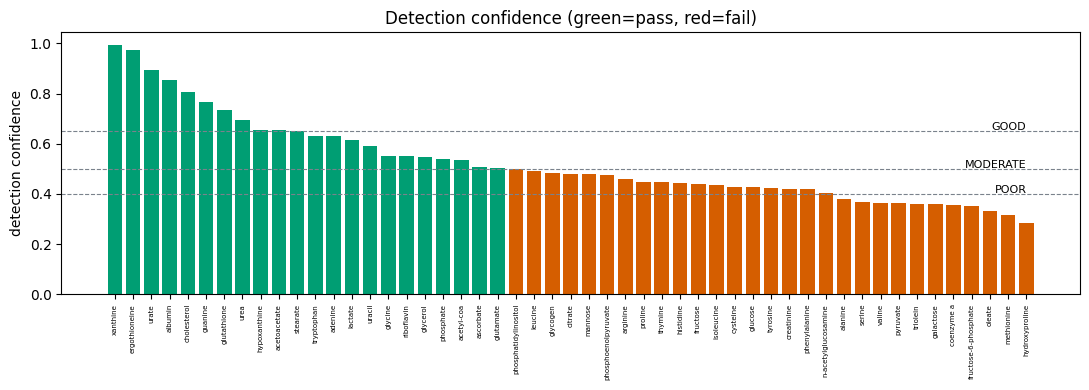

In [3]:
fig, ax = plt.subplots(figsize=(11,4))
ax.bar(range(len(df)), df.detection_confidence, color=['#009E73' if p else '#D55E00' for p in df.detection_pass])
for name,t in S['tier_thresholds'].items():
    if t>0: ax.axhline(t, ls='--', color='#7A828C', lw=0.8); ax.text(len(df)-1, t+0.005, name, fontsize=8, ha='right')
ax.set_xticks(range(len(df))); ax.set_xticklabels(df.analyte, rotation=90, fontsize=5)
ax.set_ylabel('detection confidence'); ax.set_title('Detection confidence (green=pass, red=fail)')
plt.tight_layout(); plt.show()

## 3 · Spectra: why the anchors pass or fail (mean Ag-SERS vs blank)

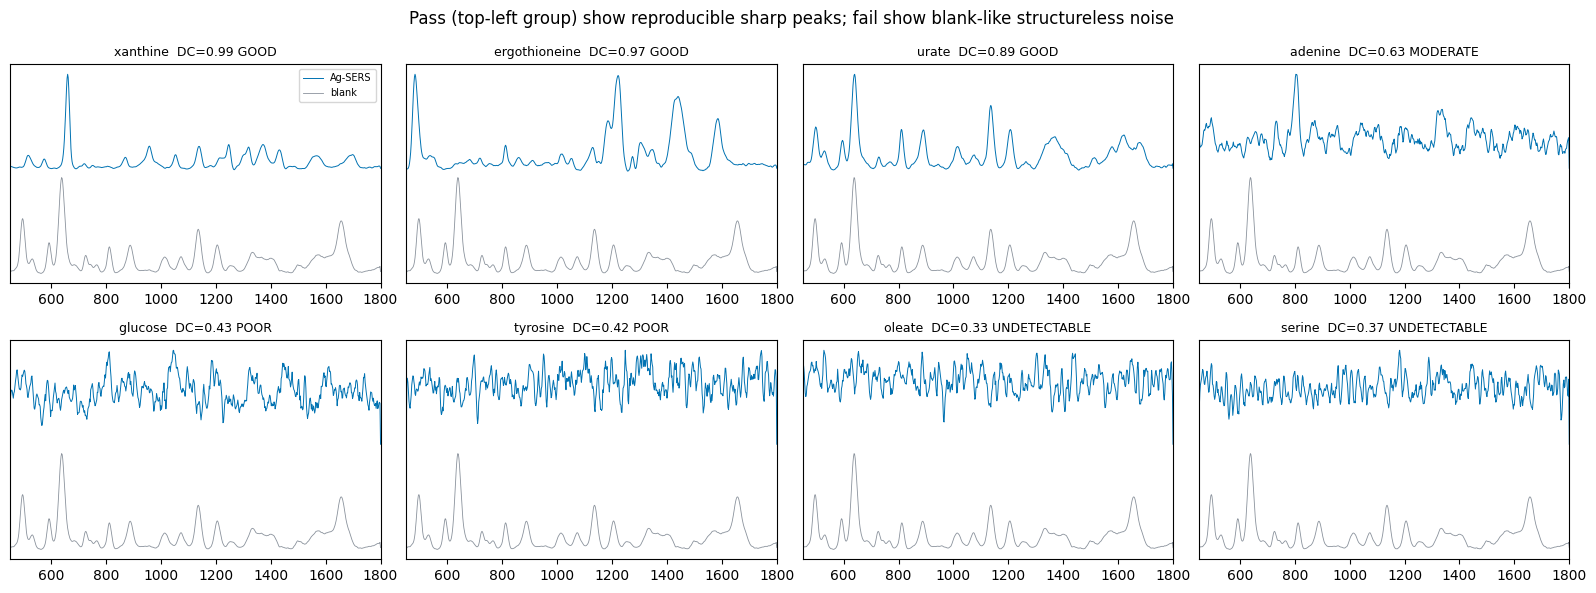

In [4]:
grid = V['grid']; blank = V['blank_mean']; AN = list(V['analytes']); SP = V['spectra']
idx = {a:i for i,a in enumerate(AN)}
picks = ['xanthine','ergothioneine','urate','adenine','glucose','tyrosine','oleate','serine']
fig, axes = plt.subplots(2,4, figsize=(16,6))
for ax,a in zip(axes.ravel(), picks):
    s = SP[idx[a]]; ax.plot(grid, s/ (s.max()+1e-9), color='#0072B2', lw=0.7, label='Ag-SERS')
    ax.plot(grid, blank/(blank.max()+1e-9)-1.1, color='#8A929C', lw=0.6, label='blank')
    r = df.set_index('analyte').loc[a]
    ax.set_title(f"{a}  DC={r.detection_confidence:.2f} {r.detection_tier}", fontsize=9)
    ax.set_yticks([]); ax.set_xlim(450,1800)
axes[0,0].legend(fontsize=7)
plt.suptitle('Pass (top-left group) show reproducible sharp peaks; fail show blank-like structureless noise')
plt.tight_layout(); plt.show()

## 4 · TUNABLE — re-score with different weights/thresholds to test robustness

In [5]:
# adjust and re-run to see how the anchors move; the frozen values are in detection_gate.py
W = {'rep_pearson':0.45,'rep_spearman':0.10,'peak_snr':0.20,'var_concentration':0.15,'repro_peaks':0.10}
SNR_CAP, VCONC_CAP, PK_CAP = 100.0, 0.25, 12
def dc(r):
    parts = {'rep_pearson':np.clip(r.rep_pearson,0,1),'rep_spearman':np.clip(r.rep_spearman,0,1),
             'peak_snr':np.clip(np.log10(r.peak_snr+1)/np.log10(SNR_CAP),0,1),
             'var_concentration':np.clip(r.var_concentration/VCONC_CAP,0,1),
             'repro_peaks':np.clip(r.repro_peaks/PK_CAP,0,1)}
    return sum(W[k]*parts[k] for k in W)
d2 = df.copy(); d2['dc_retuned'] = d2.apply(dc, axis=1)
print('anchors under retuned weights:')
print(d2.set_index('analyte').loc[['xanthine','ergothioneine','urate','adenine','glucose','tyrosine','oleate'],['detection_confidence','dc_retuned']])

anchors under retuned weights:
               detection_confidence  dc_retuned
analyte                                        
xanthine                     0.9948    0.994772
ergothioneine                0.9723    0.972280
urate                        0.8942    0.894228
adenine                      0.6306    0.630617
glucose                      0.4263    0.426254
tyrosine                     0.4227    0.422688
oleate                       0.3329    0.332912


## Validation outcome

The frozen weights `{rep_pearson 0.45, rep_spearman 0.10, peak_snr 0.20, var_concentration 0.15,
repro_peaks 0.10}` and tiers `GOOD≥0.65 / MODERATE≥0.50 / POOR≥0.40 / UNDETECTABLE<0.40`
(pass ≥ 0.50) reproduce the physically-expected pattern:

- **PASS:** xanthine 0.99, ergothioneine 0.97, urate 0.89, guanine 0.77, hypoxanthine 0.65, adenine
  0.63 — strong/moderate Ag chemisorbers with reproducible, structured spectra.
- **FAIL:** glucose 0.43, tyrosine 0.42 (POOR), oleate 0.33, serine 0.37, methionine 0.31
  (UNDETECTABLE) — poor adsorbers with blank-like, irreproducible spectra.

Anchors validated → thresholds are frozen into `detection_gate.py` and used unchanged by the V6
pipeline. The gate reflects adsorption spectroscopy (replicate reproducibility + peak structure +
SNR + variance concentration), not an arbitrary cutoff.